# Exploratory Data Analysis — RAW_interactions.csv

Notebook ini melakukan:
- Load data dari `dataset/RAW_interactions.csv`
- Preprocessing (tipe data, missing values, duplikasi, feature engineering ringan)
- EDA (ringkasan data, distribusi rating, aktivitas user/recipe, tren waktu, analisis review jika tersedia)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
DATA_DIR = Path("dataset")
RAW_INTERACTIONS_PATH = ".." / DATA_DIR / "RAW_interactions.csv"
assert RAW_INTERACTIONS_PATH.exists(), f"File not found: {RAW_INTERACTIONS_PATH.resolve()}"

df_raw = pd.read_csv(RAW_INTERACTIONS_PATH)
print("Loaded:", RAW_INTERACTIONS_PATH)
df_raw.shape

Loaded: ..\dataset\RAW_interactions.csv


(1132367, 5)

In [3]:
# Sample
display(df_raw.head(5))

print("Columns:", list(df_raw.columns))
display(df_raw.describe(include="all").T.head(30))

missing = df_raw.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].head(30))

,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


Columns: ['user_id', 'recipe_id', 'date', 'rating', 'review']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,1132367.0,NaN,NaN,NaN,138429067.430652,501426863.683784,1533.0,135470.0,330937.0,804550.0,2002372706.0
recipe_id,1132367.0,NaN,NaN,NaN,160897.208164,130398.719639,38.0,54257.0,120547.0,243852.0,537716.0
date,1132367,6396,2008-01-27,723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1132367.0,NaN,NaN,NaN,4.411016,1.264752,0.0,4.0,5.0,5.0,5.0
review,1132198,1125282,Delicious!,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN


review    169
dtype: int64

## Preprocessing

In [4]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]
df = df.drop_duplicates().reset_index(drop=True)

# Konversi kolom ke tipe yang sesuai (numeric)
for col in ["user_id", "recipe_id", "rating"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Ubah kolom tanggal ke datetime
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Clean kolom review
if "review" in df.columns:
    df["review"] = df["review"].astype("string").str.strip()
    df["review_len"] = df["review"].fillna("").str.len()

# Validasi nilai rating
if "rating" in df.columns:
    # rating in Food.com biasanya 0-5; nilai di luar range dijadikan NaN
    df.loc[(df["rating"] < 0) | (df["rating"] > 5), "rating"] = np.nan

print("After preprocessing shape:", df.shape)
df.info()
display(df.head(5))

After preprocessing shape: (1132367, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1132367 entries, 0 to 1132366
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   user_id     1132367 non-null  int64         
 1   recipe_id   1132367 non-null  int64         
 2   date        1132367 non-null  datetime64[ns]
 3   rating      1132367 non-null  float64       
 4   review      1132198 non-null  string        
 5   review_len  1132367 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(2), string(1)
memory usage: 52.9 MB


,user_id,recipe_id,date,rating,review,review_len
0,38094,40893,2003-02-17,4.0,Great with a salad. Cooked on top of stove for...,138
1,1293707,40893,2011-12-21,5.0,"So simple, so delicious! Great for chilly fall...",205
2,8937,44394,2002-12-01,4.0,This worked very well and is EASY. I used not...,99
3,126440,85009,2010-02-27,5.0,I made the Mexican topping and took it to bunk...,68
4,57222,85009,2011-10-01,5.0,"Made the cheddar bacon topping, adding a sprin...",73


## EDA

### Missing value

review    0.000149
dtype: float64

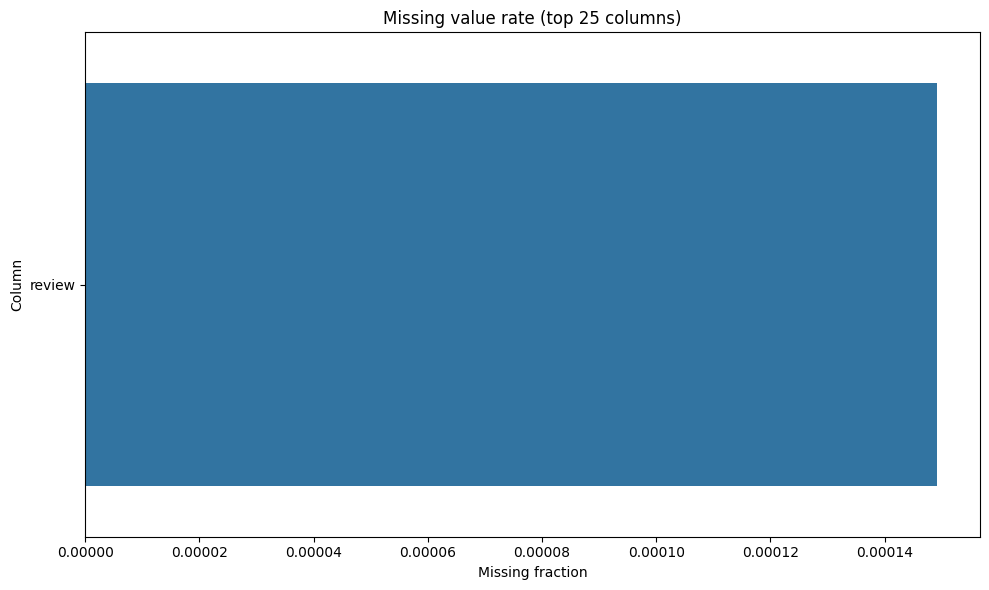

In [5]:
na_rate = df.isna().mean().sort_values(ascending=False)
na_rate = na_rate[na_rate > 0]
display(na_rate.head(30))

if not na_rate.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=na_rate.head(25).values, y=na_rate.head(25).index, orient="h")
    plt.title("Missing value rate (top 25 columns)")
    plt.xlabel("Missing fraction")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

### Distribusi Rating

rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64

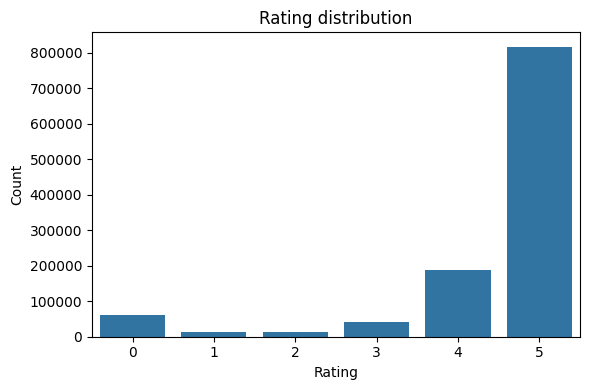

In [6]:
if "rating" in df.columns:
    rating_counts = df["rating"].dropna().astype(int).value_counts().sort_index()
    display(rating_counts)

    plt.figure(figsize=(6, 4))
    sns.barplot(x=rating_counts.index, y=rating_counts.values)
    plt.title("Rating distribution")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'rating' tidak ditemukan.")

### Interaksi per User / per Recipe

count    226570.000000
mean          4.997868
std          49.663111
min           1.000000
50%           1.000000
90%           5.000000
95%          11.000000
99%          61.000000
max        7671.000000
dtype: float64

user_id
424680     7671
37449      5603
383346     4628
169430     4076
128473     3917
89831      3353
58104      3288
133174     3107
199848     3018
305531     2902
226863     2874
4470       2739
498271     2644
369715     2610
1072593    2350
176615     2338
95743      2311
286566     2283
39835      2260
107583     2252
dtype: int64

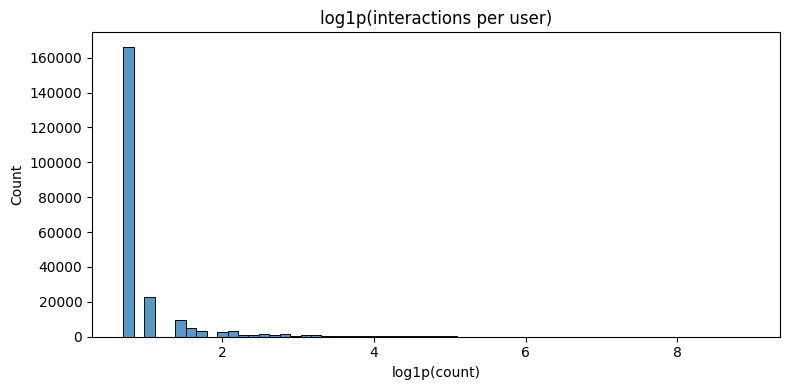

count    231637.000000
mean          4.888541
std          17.532481
min           1.000000
50%           2.000000
90%           9.000000
95%          15.000000
99%          47.000000
max        1613.000000
dtype: float64

recipe_id
2886      1613
27208     1601
89204     1579
39087     1448
67256     1322
54257     1305
22782     1234
32204     1220
69173      997
68955      904
33919      877
82102      855
25885      847
28148      802
135350     786
26110      770
99476      762
10744      731
129926     730
33671      727
dtype: int64

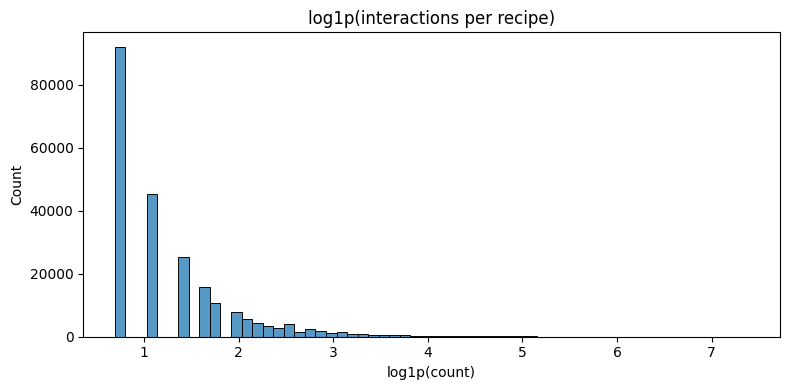

In [7]:
if "user_id" in df.columns:
    per_user = df.groupby("user_id").size()
    display(per_user.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
    top_users = per_user.sort_values(ascending=False).head(20)
    display(top_users)

    plt.figure(figsize=(8, 4))
    sns.histplot(np.log1p(per_user.values), bins=60)
    plt.title("log1p(interactions per user)")
    plt.xlabel("log1p(count)")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'user_id' tidak ditemukan.")

if "recipe_id" in df.columns:
    per_recipe = df.groupby("recipe_id").size()
    display(per_recipe.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
    top_recipes = per_recipe.sort_values(ascending=False).head(20)
    display(top_recipes)

    plt.figure(figsize=(8, 4))
    sns.histplot(np.log1p(per_recipe.values), bins=60)
    plt.title("log1p(interactions per recipe)")
    plt.xlabel("log1p(count)")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'recipe_id' tidak ditemukan.")

### Distribusi Interaksi

<>:1: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:1: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\thafa\AppData\Local\Temp\ipykernel_26596\1264143891.py:1: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if "date" is not None and pd.api.types.is_datetime64_any_dtype(df["date"]):


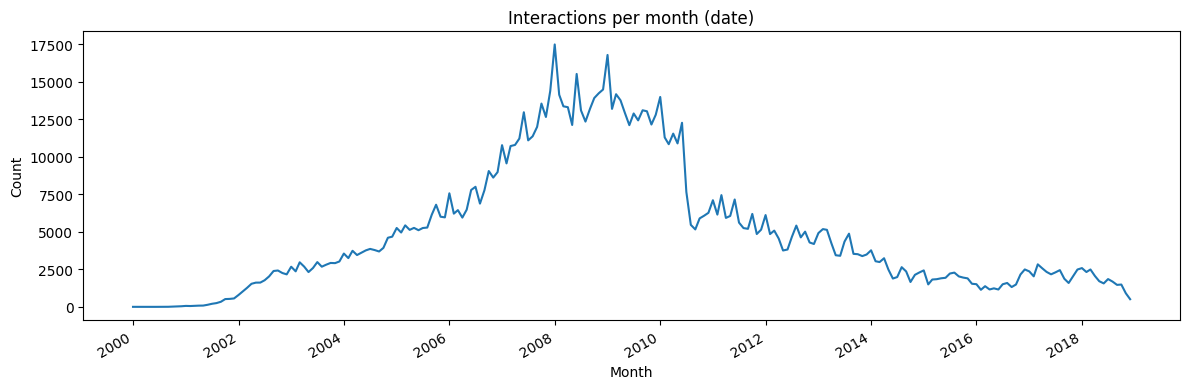

In [9]:
if "date" is not None and pd.api.types.is_datetime64_any_dtype(df["date"]):
    ts = df.dropna(subset=["date"]).copy()
    if not ts.empty:
        ts["month"] = ts["date"].dt.to_period("M").dt.to_timestamp()
        monthly = ts.groupby("month").size()
        plt.figure(figsize=(12, 4))
        monthly.plot()
        plt.title(f"Interactions per month ({df['date'].name})")
        plt.xlabel("Month")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print("Tidak ada tanggal non-null.")
else:
    print("Tidak ada kolom tanggal yang valid.")

### Panjang review

count     1132367.0
mean     278.296147
std      197.243135
min             0.0
50%           237.0
90%           512.0
95%           636.0
99%           968.0
max          6972.0
Name: review_len, dtype: Float64

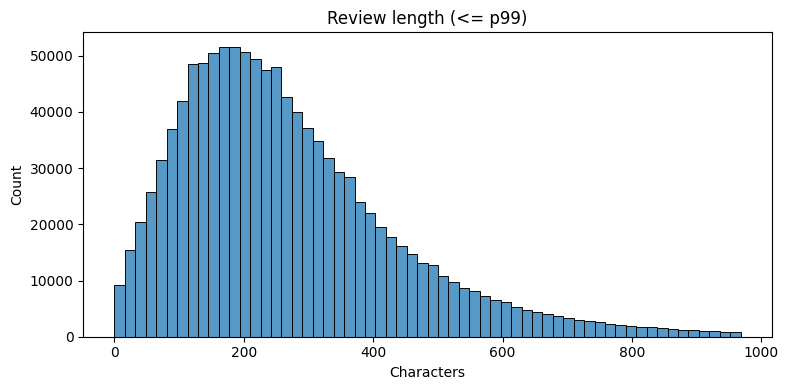

In [10]:
if "review_len" in df.columns:
    display(df["review_len"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
    plt.figure(figsize=(8, 4))
    s = df["review_len"].dropna()
    upper = s.quantile(0.99)
    sns.histplot(s[s <= upper], bins=60)
    plt.title("Review length (<= p99)")
    plt.xlabel("Characters")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada kolom 'review' yang ditemukan.")